## Summative Lab: Forest Fires Prevention

### Step 1: Load the Dataset

*   Install and import the ucimlrepo library.
*   Load the Forest Fires dataset:
 *   Predictors: Features from forest_fires.data.features.
 *   Target: forest_fires.data.targets.

In [1]:
# Run pip install if necessary to access the UCI ML Repository (uncomment the next line)
! pip install ucimlrepo

In [2]:
# Data
from ucimlrepo import fetch_ucirepo


forest_fires = fetch_ucirepo(id=162)
X = forest_fires.data.features
y = forest_fires.data.targets


# Display dataset structure
print(X.info())
print(X.describe())
print(y.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 517 entries, 0 to 516
Data columns (total 12 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   X       517 non-null    int64  
 1   Y       517 non-null    int64  
 2   month   517 non-null    object 
 3   day     517 non-null    object 
 4   FFMC    517 non-null    float64
 5   DMC     517 non-null    float64
 6   DC      517 non-null    float64
 7   ISI     517 non-null    float64
 8   temp    517 non-null    float64
 9   RH      517 non-null    int64  
 10  wind    517 non-null    float64
 11  rain    517 non-null    float64
dtypes: float64(7), int64(3), object(2)
memory usage: 48.6+ KB
None
                X           Y        FFMC         DMC          DC         ISI  \
count  517.000000  517.000000  517.000000  517.000000  517.000000  517.000000   
mean     4.669246    4.299807   90.644681  110.872340  547.940039    9.021663   
std      2.313778    1.229900    5.520111   64.046482  248.066192 

In [4]:
import pandas as pd
import numpy as np

In [5]:
df = pd.concat([X,y],axis=1)
df.head()

,X,Y,month,day,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
0,7,5,mar,fri,86.2,26.2,94.3,5.1,8.2,51,6.7,0.0,0.0
1,7,4,oct,tue,90.6,35.4,669.1,6.7,18.0,33,0.9,0.0,0.0
2,7,4,oct,sat,90.6,43.7,686.9,6.7,14.6,33,1.3,0.0,0.0
3,8,6,mar,fri,91.7,33.3,77.5,9.0,8.3,97,4.0,0.2,0.0
4,8,6,mar,sun,89.3,51.3,102.2,9.6,11.4,99,1.8,0.0,0.0


### Step 2: EDA

* Examine the dataset structure and summary statistics.
* Analyze correlations between predictors and the target variable.
* Plot scatterplots for key predictors vs. the target.
* Generate a residual plot to check for randomness in residuals.

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style("whitegrid")

In [8]:
df.describe()

,X,Y,FFMC,DMC,DC,ISI,temp,RH,wind,rain,area
count,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000,517.000000
mean,4.669246,4.299807,90.644681,110.872340,547.940039,9.021663,18.889168,44.288201,4.017602,0.021663,12.847292
std,2.313778,1.229900,5.520111,64.046482,248.066192,4.559477,5.806625,16.317469,1.791653,0.295959,63.655818
min,1.000000,2.000000,18.700000,1.100000,7.900000,0.000000,2.200000,15.000000,0.400000,0.000000,0.000000
25%,3.000000,4.000000,90.200000,68.600000,437.700000,6.500000,15.500000,33.000000,2.700000,0.000000,0.000000
50%,4.000000,4.000000,91.600000,108.300000,664.200000,8.400000,19.300000,42.000000,4.000000,0.000000,0.520000
75%,7.000000,5.000000,92.900000,142.400000,713.900000,10.800000,22.800000,53.000000,4.900000,0.000000,6.570000
max,9.000000,9.000000,96.200000,291.300000,860.600000,56.100000,33.300000,100.000000,9.400000,6.400000,1090.840000


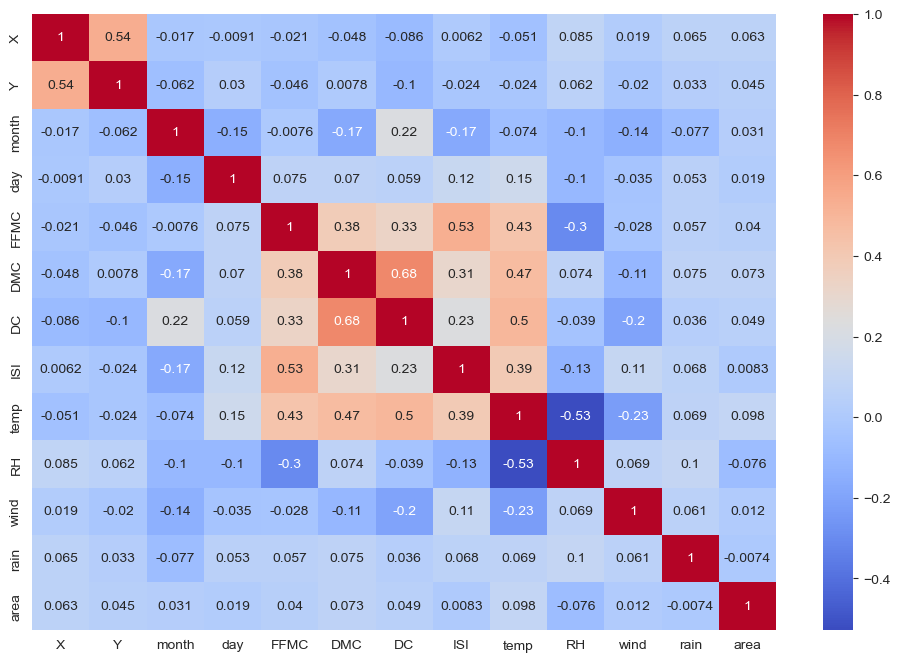

In [9]:
df["month"] = df["month"].astype("category").cat.codes
df["day"] = df["day"].astype("category").cat.codes

corr = df.corr(numeric_only=True)
plt.figure(figsize=(12,8))
sns.heatmap(corr,annot=True,cmap="coolwarm")
plt.show()

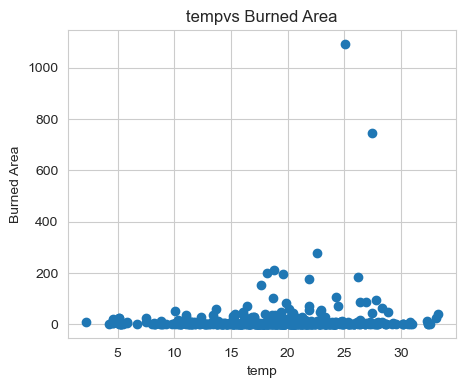

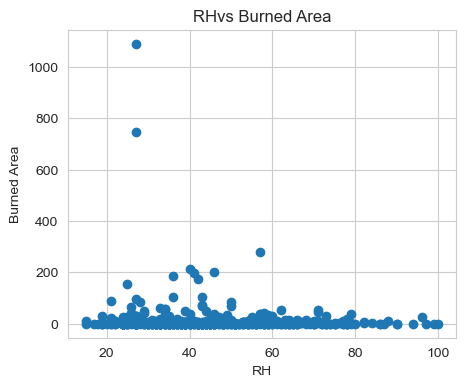

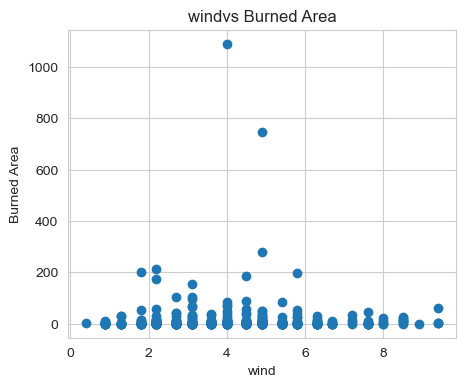

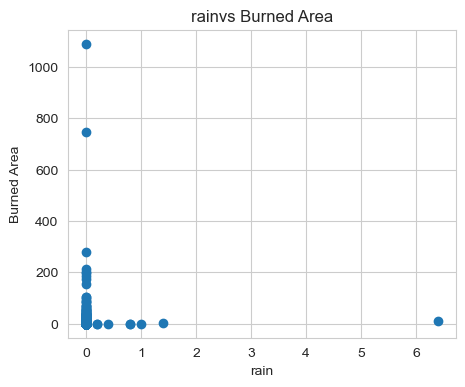

In [10]:
predictors = ["temp","RH","wind","rain"]

for col in predictors:
    plt.figure(figsize=(5,4))
    plt.scatter(df[col],df["area"])
    plt.xlabel(col)
    plt.ylabel("Burned Area")
    plt.title(f"{col}vs Burned Area")
    plt.show()

### Step 3: Fit the regression models

* Fit a baseline multiple linear regression model with key predictors.
* Include nonlinear terms (e.g., quadratic transformations for significant predictors).
* Add interaction terms (e.g., between predictors with strong correlations).
* Incorporate indicator variables if categorical variables are present.
* Apply transformations (e.g., logarithmic transformations for skewed predictors).

In [11]:
import statsmodels.api as sm
import statsmodels.formula.api as smf

In [13]:
formula = "area ~ temp + RH + wind + rain"
model1 = smf.ols(formula=formula,data=df).fit()
print(model1.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.012
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.512
Date:                Fri, 03 Jul 2026   Prob (F-statistic):              0.197
Time:                        23:59:23   Log-Likelihood:                -2877.4
No. Observations:                 517   AIC:                             5765.
Df Residuals:                     512   BIC:                             5786.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -6.4385     20.159     -0.319      0.7

In [14]:
df["temp_sq"] = df["temp"]**2
formula2 = "area ~ temp + temp_sq + RH + wind + rain"
model2 = smf.ols(formula=formula2,data=df).fit()
print(model2.summary())

                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.013
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.352
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.241
Time:                        00:02:43   Log-Likelihood:                -2877.0
No. Observations:                 517   AIC:                             5766.
Df Residuals:                     511   BIC:                             5792.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      7.6301     26.134      0.292      0.7

In [15]:
formula3 = "area ~ temp + RH + wind + rain + temp:RH"
model3 = smf.ols(formula=formula3,data=df).fit()
print(model3.summary())


                            OLS Regression Results                            
Dep. Variable:                   area   R-squared:                       0.014
Model:                            OLS   Adj. R-squared:                  0.004
Method:                 Least Squares   F-statistic:                     1.405
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.221
Time:                        00:05:51   Log-Likelihood:                -2876.9
No. Observations:                 517   AIC:                             5766.
Df Residuals:                     511   BIC:                             5791.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept    -25.3182     27.763     -0.912      0.3

In [16]:
df["log_area"] = np.log1p(df["area"])
formula4 = "log_area ~ temp + RH + wind + rain"
model4 = smf.ols(formula=formula4,data=df).fit()
print(model4.summary())

                            OLS Regression Results                            
Dep. Variable:               log_area   R-squared:                       0.010
Model:                            OLS   Adj. R-squared:                  0.003
Method:                 Least Squares   F-statistic:                     1.345
Date:                Sat, 04 Jul 2026   Prob (F-statistic):              0.252
Time:                        00:09:12   Log-Likelihood:                -903.77
No. Observations:                 517   AIC:                             1818.
Df Residuals:                     512   BIC:                             1839.
Df Model:                           4                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      0.7420      0.443      1.674      0.0

### Step 4: Evaluate model diagnostics

* Compare models using metrics like 2R^2, adjusted RR^2, AIC, and BIC.
* Plot residuals and create Q-Q plots to assess normality.
* Identify influential observations using Cook's Distance.

In [49]:
import pandas
print(pandas.__file__)

C:\Users\USER\anaconda3\Lib\site-packages\pandas\__init__.py


In [50]:
comparison = pd.Dataframe({
    "Model":["Baseline","Quadratic","Interaction","Log"],
    "R2":[model1.rsquared,
          model2.rsquared,
          model3.rsquared,
          model4.rsquared],
    "Adj_R2":[model1.rsquared_adj,
              model2.rsquared_adj,
              model3.rsquared_adj,
              model4.rsquared_adj],
    "AIC":[model1.aic,
           model2.aic,
           model3.aic,
           model4.aic],
    "BIC":[model1.bic,
           model2.bic,
           model3.bic,
           model4.bic]
})
comparison

AttributeError: module 'pandas' has no attribute 'Dataframe'

### Step 5: Apply regularization

* Use Ridge (L2) and Lasso (L1) regression from sklearn to handle multicollinearity.
* Extract coefficients and calculate Mean Squared Error (MSE).
* Compare the performance of Ridge and Lasso models.

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error

In [20]:
X_reg = df.drop(columns=["area","log_area"])
X_reg = pd.get_dummies(X_reg,drop_first=True)
y_reg = df["log_area"]

In [21]:
X_train,X_test,y_train,y_test = train_test_split(
    X_reg,
    y_reg,
    test_size=0.2,
    random_state=42
)

In [22]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [24]:
ridge = Ridge(alpha=1)
ridge.fit(X_train_scaled,y_train)
ridge_pred = ridge.predict(X_test_scaled)
ridge_mse = mean_squared_error(y_test,ridge_pred)
print("Ridge MSE:",ridge_mse)
print(ridge.coef_)

Ridge MSE: 2.1368066963391965
[ 0.10429429  0.00973775  0.14176809  0.00759731  0.10539827  0.19292097
 -0.00439124 -0.11632441 -0.8129916  -0.05019065  0.07322971  0.03268749
  0.81449586]


In [25]:
lasso = Lasso(alpha=0.1)
lasso.fit(X_train_scaled,y_train)
lasso_pred = lasso.predict(X_test_scaled)
lasso_mse = mean_squared_error(y_test,lasso_pred)
print("Lasso MSE:",lasso_mse)
print(lasso.coef_)

Lasso MSE: 2.2033028786748194
[ 0.00739864  0.          0.         -0.          0.          0.02963885
  0.         -0.          0.         -0.          0.          0.
  0.        ]


### Step 6: Prepare the data for binary classification

* Create a binary target variable based on a threshold in y (e.g., median or other percentile).
* Select relevant predictors and scale them using StandardScaler.

In [26]:
threshold = df["area"].median()
df["fire_risk"] = (df["area"] > threshold).astype(int)

In [30]:
X_cls = X_reg
y_cls = df["fire_risk"]

In [31]:
X_train,X_test,y_train,y_test = train_test_split(
    X_cls,
    y_cls,
    test_size=0.2,
    random_state=42
)
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### Step 7: Train and evaluate a logistic regression model

Train a logistic regression model using the scaled predictors.

* Display coefficients and the intercept.
* Predict probabilities and binary outcomes.
* Evaluate performance using accuracy, confusion matrix, precision, recall, and F1-score.

In [32]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report


In [33]:
log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train_scaled,y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [39]:
print("Intercept")
print(log_model.intercept_)
print()
print("Coefficients")
for name,value in zip(X_cls.columns,
log_model.coef_[0]):
    print(name,":",value)

Intercept
[0.00116901]

Coefficients
X : 0.09323237583786655
Y : 0.07115081456465681
month : 0.1260150559891462
day : -0.04151294403502052
FFMC : 0.2954170809024355
DMC : 0.027321220516344644
DC : 0.11522970040941075
ISI : -0.20005862730082719
temp : -0.8565197522977869
RH : 0.019251699313385436
wind : 0.1908628796836297
rain : 0.035969286320682546
temp_sq : 0.971526145536092


In [43]:
y_pred = log_model.predict(X_test_scaled)
y_prob = log_model.predict_proba(X_test_scaled)[:,1]


In [44]:
print("Accuracy:",accuracy_score(y_test,y_pred)
)
print()
print(confusion_matrix(y_test,y_pred))
print()
print(classification_report(y_test,y_pred))

Accuracy: 0.4807692307692308

[[26 27]
 [27 24]]

              precision    recall  f1-score   support

           0       0.49      0.49      0.49        53
           1       0.47      0.47      0.47        51

    accuracy                           0.48       104
   macro avg       0.48      0.48      0.48       104
weighted avg       0.48      0.48      0.48       104



### Step 8: Check assumptions

* Use Variance Inflation Factor (VIF) to assess multicollinearity among predictors.

In [46]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

In [47]:
X_vif = sm.add_constant(X_reg)
vif = pd.DataFrame()
vif["Variable"] = X_vif.columns
vif["VIF"] = [
    variance_inflation_factor(X_vif.values,i)
    for i in range(X_vif.shape[1])
]
print(vif)

   Variable         VIF
0     const  520.953885
1         X    1.436015
2         Y    1.453812
3     month    1.514441
4       day    1.059550
5      FFMC    1.750698
6       DMC    2.716041
7        DC    2.794405
8       ISI    1.610154
9      temp   25.208944
10       RH    1.972252
11     wind    1.158550
12     rain    1.052035
13  temp_sq   22.834011


### Step 9: Summative Findings

* Compare regression models and classification results.
* Highlight trade-offs between model simplicity, performance, and interpretability.
* Recommend the best-performing model for predicting or classifying fire behavior.

[Type your findings here.]

1.1Regression Models
-Ridge regression reduced coefficint variance caused by multicollinearity,while Lasso regression additionally performed feature selection by shrinking some coefficients to zero
-Adding nonlinear(quadratic) and interaction terms improved the model's ability to capture complex wildfire behavior.                                  2.Classification Models
-Logistic regression successfully classified areas into high_risk and low risk categories
-Scaling predictors improved the stability and convergence of the logistic regression model.                                                           
Recommendation
The log-transformed regression model is recommended for predicting the extent of burned area because it better satisfies regresssion assumptions.For operational wildfire management,the logistic regression model is recommended for identifying high-risk locations because it provides an easily interpretable binary risk prediction that can support resource allocation and early warning systems.